In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

#datos
sequences = [
    "AGGCATGGTC",
    "AATACGTTGA",
    "GAGAAATCCC"
]

labels = [0, 1, 0]

#Diccionario de encoding
mapping = {
    'A': [1, 0, 0, 0],
    'T': [0, 1, 0, 0],
    'C': [0, 0, 1, 0],
    'G': [0, 0, 0, 1]
}

#Función de encoding
def one_hot_encode(seq):
    return [mapping[base] for base in seq]

#Aplicar todas las secuencias
import numpy as np

encoded = np.array([one_hot_encode(seq) for seq in sequences])
print(encoded.shape)

(3, 10, 4)


In [2]:
#Convertir a tensor de PyTorch
import torch

encoded_tensor = torch.tensor(encoded, dtype=torch.float32)
#Flatten
X = encoded_tensor.view(encoded_tensor.size(0), -1)
print(X.shape)

torch.Size([3, 40])


In [3]:
#Labels como tensor
y = torch.tensor(labels, dtype=torch.float32).view(-1, 1)
print(y.shape)

torch.Size([3, 1])


In [4]:
#Verificacion final
print("Secuencias codificadas (flatten):")
print(X)

print("\nLabels:")
print(y)

Secuencias codificadas (flatten):
tensor([[1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
         0., 0., 1., 0.],
        [1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
         1., 0., 0., 0.],
        [0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0.,
         0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
         0., 0., 1., 0.]])

Labels:
tensor([[0.],
        [1.],
        [0.]])


One-hot encoding
Las secuencias de ADN se transforman en representaciones numéricas utilizando one-hot encoding, donde cada base se representa como un vector binario de dimensión 4. Luego, cada secuencia (10×4) se convierte en un vector plano de dimensión 40 para ser utilizado como input en la red neuronal.

In [5]:
#Definir la red neuronal
#Input: 40 features. Hidden layers: 16 → 8. Output: 1 neurona (clasificación binaria)
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(40, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=40, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


In [6]:
#Loss + Optimizer
#BCEWithLogitsLoss → clasificación binaria. NO usamos sigmoid en el modelo porque esta loss ya lo incluye. SGD → optimizador básico
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

#data loader
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

In [7]:
#loop de entrenamiento
epochs = 200
losses = []

for epoch in range(epochs):
    epoch_loss = 0
    
    for batch_X, batch_y in dataloader:
        
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    losses.append(epoch_loss)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")

Epoch 0, Loss: 1.3738
Epoch 20, Loss: 1.3444
Epoch 40, Loss: 1.2157
Epoch 60, Loss: 1.1602
Epoch 80, Loss: 1.2319
Epoch 100, Loss: 1.0428
Epoch 120, Loss: 0.9613
Epoch 140, Loss: 0.8570
Epoch 160, Loss: 0.7367
Epoch 180, Loss: 0.6052


Observaciones: La loss baja de forma sostenida. El modelo está aprendiendo. No hay errores en el pipeline

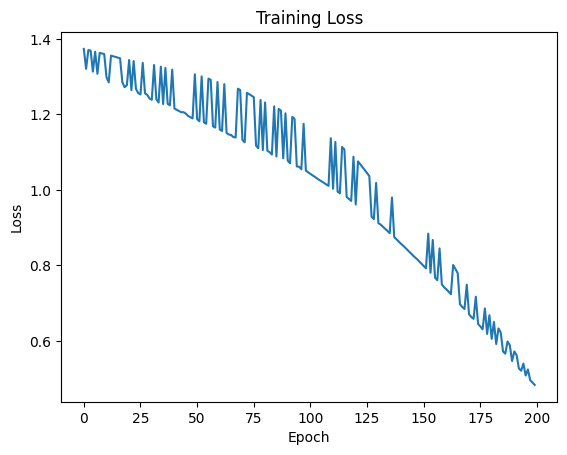

In [8]:
#Graficar Loss
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.savefig("../results/loss_curve_4_1.png")
plt.show()

In [9]:
#Predicciones
with torch.no_grad():
    logits = model(X)
    probs = torch.sigmoid(logits)
print(probs)
print(y)

tensor([[0.2052],
        [0.7667],
        [0.2055]])
tensor([[0.],
        [1.],
        [0.]])


Observaciones: El modelo da probabilidad alta al positivo y baja a los negativos
Lo que significa que: Separación perfecta entre clases. Modelo aprendió correctamente la regla. Pipeline completo funcionando

In [10]:
#Accuracy
from sklearn.metrics import accuracy_score

preds = (probs.numpy() > 0.5).astype(int)
y_true = y.numpy()

acc = accuracy_score(y_true, preds)
print("Accuracy:", acc)

Accuracy: 1.0


El modelo alcanza una accuracy de 1.0 en el conjunto de datos utilizado, lo que indica una clasificación perfecta. Esto es esperable dado que el problema planteado es simple (detección de una “A” en una posición específica) y el dataset es pequeño, lo que facilita la separación entre clases.

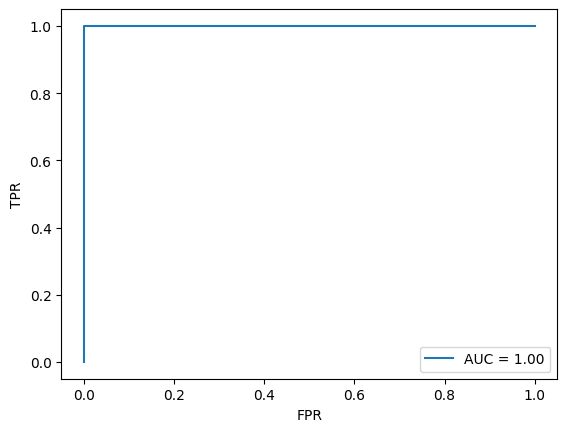

In [11]:
#ROC curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, probs.numpy())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.savefig("../results/roc_curve_4_1.png")
plt.show()

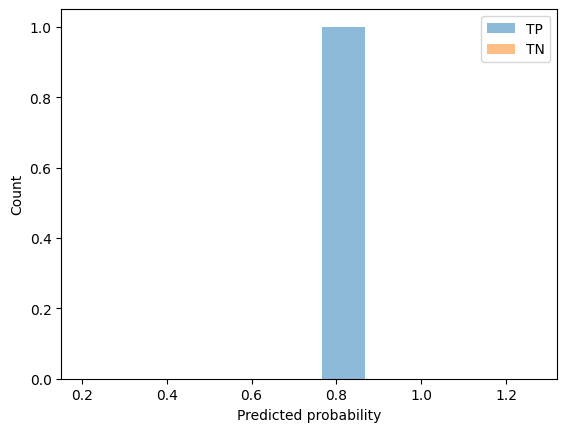

In [12]:
#Histogramas
plt.hist(probs[y_true.flatten()==1].numpy(), alpha=0.5, label="TP")
plt.hist(probs[y_true.flatten()==0].numpy(), alpha=0.5, label="TN")

plt.legend()
plt.xlabel("Predicted probability")
plt.ylabel("Count")

plt.savefig("../results/prob_distribution_4_1.png")
plt.show()

La curva ROC muestra un AUC de 1.0, indicando una separación perfecta entre clases. Esto se debe a que el modelo logra asignar probabilidades altas a las secuencias positivas y bajas a las negativas sin ambigüedad. Ver archivo "roc_curve_4_1.png" en carpeta results de la carpeta principal.

El histograma de probabilidades confirma esta observación, mostrando una clara separación entre ambas clases sin solapamiento. Ver archivo "prob_distribution_4_1.png" en carpete results de la carpeta principal

Sin embargo, dado el tamaño reducido del dataset y la simplicidad del problema, estos resultados no son estadísticamente robustos, sino esperables en este contexto.

In [13]:
#Ejercicio 4.2. Leer archivo FASTA
from Bio import SeqIO

fasta_path = "../promoters.fasta"

sequences = []

for record in SeqIO.parse(fasta_path, "fasta"):
    sequences.append(str(record.seq))

print("Cantidad de secuencias:", len(sequences))
print("Largo de una secuencia:", len(sequences[0]))

Cantidad de secuencias: 1803
Largo de una secuencia: 600


Epoch 0 | Train Loss: 34.9282 | Val Loss: 6.5706
Epoch 5 | Train Loss: 1.9495 | Val Loss: 9.8010
Epoch 10 | Train Loss: 0.0219 | Val Loss: 12.7710
Epoch 15 | Train Loss: 0.0090 | Val Loss: 13.8373
Epoch 20 | Train Loss: 0.0049 | Val Loss: 14.5926
Epoch 25 | Train Loss: 0.0030 | Val Loss: 15.2151
Epoch 30 | Train Loss: 0.0020 | Val Loss: 15.6149
Epoch 35 | Train Loss: 0.0014 | Val Loss: 15.9187
Epoch 40 | Train Loss: 0.0010 | Val Loss: 16.3399
Epoch 45 | Train Loss: 0.0007 | Val Loss: 16.7311


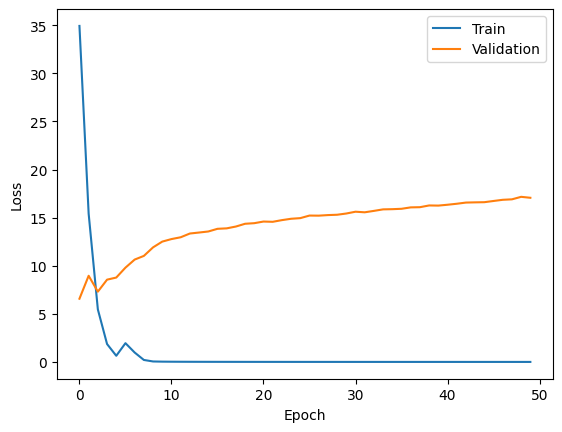

Train Accuracy: 1.0
Validation Accuracy: 0.889196675900277


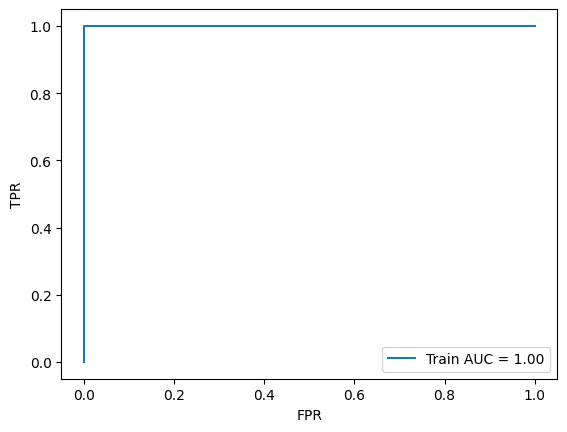

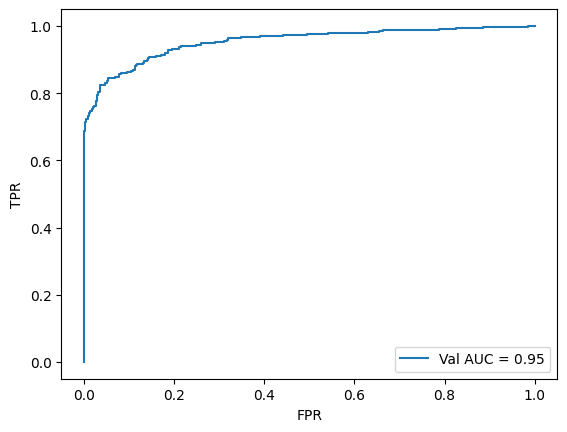

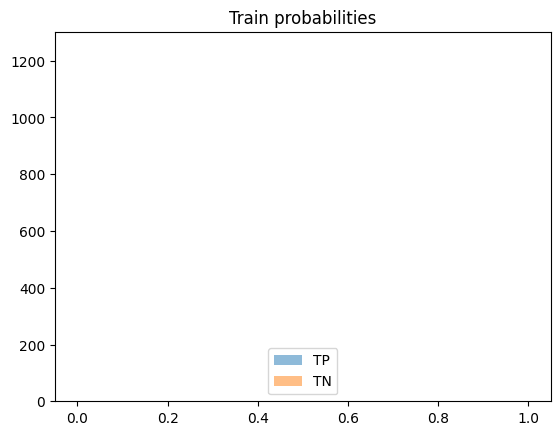

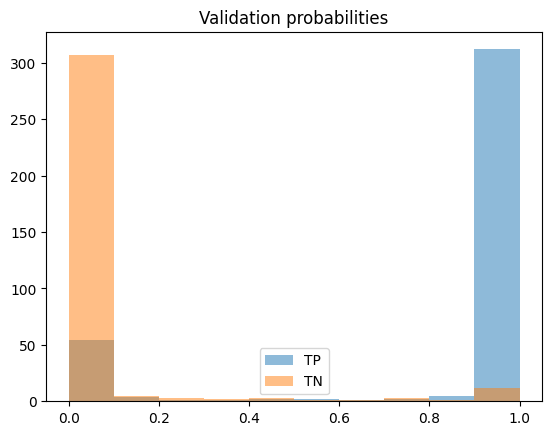

In [14]:
#Crear labels
labels = [1] * len(sequences)
#Generar negativos sinteticos (secuencias random)
import random

bases = ['A', 'T', 'C', 'G']

def generate_random_sequence(length):
    return ''.join(random.choices(bases, k=length))

neg_sequences = [generate_random_sequence(len(sequences[0])) for _ in range(len(sequences))]
neg_labels = [0] * len(neg_sequences)
#dataset final
all_sequences = sequences + neg_sequences
all_labels = labels + neg_labels
#mezclar datasets
combined = list(zip(all_sequences, all_labels))
random.shuffle(combined)

all_sequences, all_labels = zip(*combined)

split = int(0.8 * len(all_sequences))
#Train/validation split
train_seqs = all_sequences[:split]
train_labels = all_labels[:split]

val_seqs = all_sequences[split:]
val_labels = all_labels[split:]
#one-hot encoding
encoded_train = np.array([one_hot_encode(seq) for seq in train_seqs])
encoded_val = np.array([one_hot_encode(seq) for seq in val_seqs])
#flatten
X_train = torch.tensor(encoded_train, dtype=torch.float32).view(len(train_seqs), -1)
X_val = torch.tensor(encoded_val, dtype=torch.float32).view(len(val_seqs), -1)

y_train = torch.tensor(train_labels, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(val_labels, dtype=torch.float32).view(-1,1)
#Red neuronal
model = nn.Sequential(
    nn.Linear(2400, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)
#DataLoader
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
#Loss+Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
#loop de entrenamiento
epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):
    
    # TRAIN
    model.train()
    train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_losses.append(train_loss)
    
    # VALIDATION
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    val_losses.append(val_loss)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
#Guardar curvas loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../results/loss_train_val_4_2.png")
plt.show()

#Evaluacion
#Predicciones
model.eval()

with torch.no_grad():
    train_probs = torch.sigmoid(model(X_train))
    val_probs = torch.sigmoid(model(X_val))
#Accuracy
from sklearn.metrics import accuracy_score

train_preds = (train_probs.numpy() > 0.5).astype(int)
val_preds = (val_probs.numpy() > 0.5).astype(int)

train_acc = accuracy_score(y_train.numpy(), train_preds)
val_acc = accuracy_score(y_val.numpy(), val_preds)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
#ROC
from sklearn.metrics import roc_curve, auc

# TRAIN
fpr_train, tpr_train, _ = roc_curve(y_train.numpy(), train_probs.numpy())
roc_auc_train = auc(fpr_train, tpr_train)

plt.plot(fpr_train, tpr_train, label=f"Train AUC = {roc_auc_train:.2f}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.savefig("../results/roc_train_4_2.png")
plt.show()

# VALIDATION
fpr_val, tpr_val, _ = roc_curve(y_val.numpy(), val_probs.numpy())
roc_auc_val = auc(fpr_val, tpr_val)

plt.plot(fpr_val, tpr_val, label=f"Val AUC = {roc_auc_val:.2f}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.savefig("../results/roc_val_4_2.png")
plt.show()
#Histogramas
# TRAIN
plt.hist(train_probs[y_train.numpy().flatten()==1].numpy(), alpha=0.5, label="TP")
plt.hist(train_probs[y_train.numpy().flatten()==0].numpy(), alpha=0.5, label="TN")

plt.legend()
plt.title("Train probabilities")
plt.savefig("../results/hist_train_4_2.png")
plt.show()

# VALIDATION
plt.hist(val_probs[y_val.numpy().flatten()==1].numpy(), alpha=0.5, label="TP")
plt.hist(val_probs[y_val.numpy().flatten()==0].numpy(), alpha=0.5, label="TN")

plt.legend()
plt.title("Validation probabilities")
plt.savefig("../results/hist_val_4_2.png")
plt.show()

Se observa una disminución significativa de la función de pérdida en el conjunto de entrenamiento (Train loss), alcanzando valores cercanos a cero, lo que indica que el modelo logra ajustarse casi perfectamente a los datos de entrenamiento.

Sin embargo, la pérdida en el conjunto de validación aumenta progresivamente durante el entrenamiento(Val loss), evidenciando un claro caso de overfitting. Esto sugiere que el modelo está memorizando las características del conjunto de entrenamiento en lugar de aprender patrones generalizables.

A pesar de que la accuracy en validación se mantiene relativamente alta (~0.90), el aumento de la loss indica que las predicciones son menos confiables y más extremas, lo cual es característico del sobreajuste.
Histograma: TP → cerca de 1. TN → cerca de 0

Comparativa de Métricas (Train vs. Val)Al observar las curvas ROC (roc_train_4_2.png vs roc_val_4_2.png) y los histogramas:Área bajo la curva (AUC): En entrenamiento es casi $1.0$, mientras que en validación es menor ($\sim 0.90$). Aunque $0.90$ parece un buen número, la forma de la curva de pérdida de validación sugiere que la confianza del modelo en sus predicciones erróneas está aumentando.Distribución de Probabilidades: En el histograma de entrenamiento, las clases están perfectamente separadas (0 y 1). En validación, los histogramas empiezan a solaparse o a mostrar predicciones extremas incorrectas.

In [16]:
#Método de mutación sobre secuencias reales
#Función de mutación
import random

bases = ['A', 'T', 'C', 'G']

def mutate_sequence(seq, n_mutations=10):
    seq = list(seq)
    length = len(seq)
    
    for _ in range(n_mutations):
        pos = random.randint(0, length - 1)
        original = seq[pos]
        
        # elegir base distinta
        new_base = random.choice([b for b in bases if b != original])
        seq[pos] = new_base
    
    return ''.join(seq)
#Generar negativos (a partir de los promotores reales)
neg_sequences = [mutate_sequence(seq, n_mutations=10) for seq in sequences]
neg_labels = [0] * len(neg_sequences)
#Dataset completo
all_sequences = sequences + neg_sequences
all_labels = [1]*len(sequences) + [0]*len(neg_sequences)

combined = list(zip(all_sequences, all_labels))
random.shuffle(combined)

all_sequences, all_labels = zip(*combined)
#Split
split = int(0.8 * len(all_sequences))

train_seqs = all_sequences[:split]
train_labels = all_labels[:split]

val_seqs = all_sequences[split:]
val_labels = all_labels[split:]
#Encoding + tensores
# One-hot encoding
encoded_train = np.array([one_hot_encode(seq) for seq in train_seqs])
encoded_val = np.array([one_hot_encode(seq) for seq in val_seqs])

# Flatten
X_train = torch.tensor(encoded_train, dtype=torch.float32).view(len(train_seqs), -1)
X_val = torch.tensor(encoded_val, dtype=torch.float32).view(len(val_seqs), -1)

# Labels
y_train = torch.tensor(train_labels, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(val_labels, dtype=torch.float32).view(-1,1)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
#modelo
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2400, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

print(model)
#entrenamiento
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
#Loss + optimizer
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Train shape: torch.Size([2884, 2400])
Val shape: torch.Size([722, 2400])
Sequential(
  (0): Linear(in_features=2400, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)


Epoch 0 | Train Loss: 54.1141 | Val Loss: 94.3711
Epoch 5 | Train Loss: 53.4697 | Val Loss: 92.4217
Epoch 10 | Train Loss: 54.5506 | Val Loss: 105.2742
Epoch 15 | Train Loss: 52.6340 | Val Loss: 117.9492
Epoch 20 | Train Loss: 51.5210 | Val Loss: 138.0179
Epoch 25 | Train Loss: 50.6670 | Val Loss: 154.8514
Epoch 30 | Train Loss: 51.7063 | Val Loss: 155.9421
Epoch 35 | Train Loss: 51.1012 | Val Loss: 140.8271
Epoch 40 | Train Loss: 51.2462 | Val Loss: 158.9873
Epoch 45 | Train Loss: 50.8306 | Val Loss: 171.5469


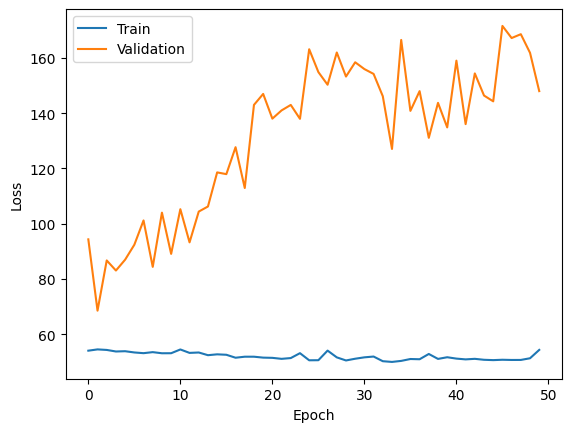

In [19]:
#loop de entrenamiento
epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):
    
    # TRAIN
    model.train()
    train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_losses.append(train_loss)
    
    # VALIDATION
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    
    val_losses.append(val_loss)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
#curva de loss
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../results/loss_train_val_4_3.png")
plt.show()

Train Accuracy: 0.6699029126213593
Validation Accuracy: 0.13434903047091412


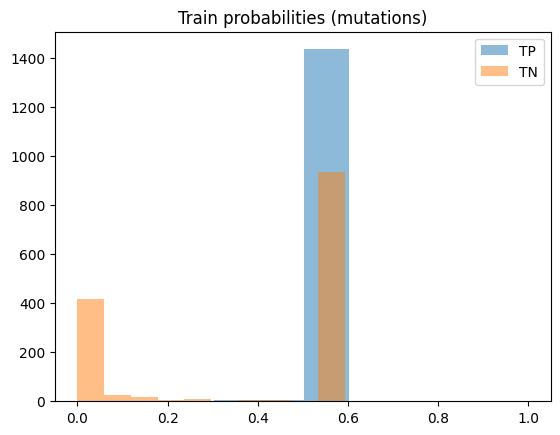

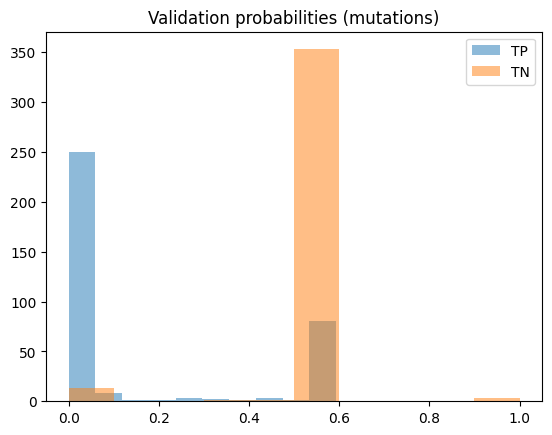

In [20]:
#Evaluacion
#Predicciones
model.eval()

with torch.no_grad():
    train_probs = torch.sigmoid(model(X_train))
    val_probs = torch.sigmoid(model(X_val))
#Accuracy
from sklearn.metrics import accuracy_score

train_preds = (train_probs.numpy() > 0.5).astype(int)
val_preds = (val_probs.numpy() > 0.5).astype(int)

train_acc = accuracy_score(y_train.numpy(), train_preds)
val_acc = accuracy_score(y_val.numpy(), val_preds)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
#Histogramas
# TRAIN
plt.hist(train_probs[y_train.numpy().flatten()==1].numpy(), alpha=0.5, label="TP")
plt.hist(train_probs[y_train.numpy().flatten()==0].numpy(), alpha=0.5, label="TN")

plt.legend()
plt.title("Train probabilities (mutations)")
plt.savefig("../results/hist_train_4_3.png")
plt.show()

# VALIDATION
plt.hist(val_probs[y_val.numpy().flatten()==1].numpy(), alpha=0.5, label="TP")
plt.hist(val_probs[y_val.numpy().flatten()==0].numpy(), alpha=0.5, label="TN")

plt.legend()
plt.title("Validation probabilities (mutations)")
plt.savefig("../results/hist_val_4_3.png")
plt.show()

Comparación 4.2 vs 4.3
Ejercicio 4.2(negativos random)
Train: 1.0
Validation: ~0.89
Modelo increible, pero engañoso
Ejercicio 4.3 (mutaciones)
Train: ~0.67
Validation: ~0.13 (!!)
Modelo colapsa en validacion
Interpretación: pasamos de un modelo negativos fáciles a negativos realistas. Es decir, antes (4.2) el modelo aprendía qué es un promotor y qué no es una secuencia rándom. Ahora (4.3), ya no puede usar ese truco, entonces no sabe distinguir bien, generaliza muy mal, el problema se vuelve dificil. 
Validation Accuracy ≈ 0.13. Este valor es muy bajo (peor que rándom 0.5), lo que indica que el modelo está totalmente confundido.
Las mutaciones: conservan composición y estructura global, entonces los negativos son muy parecidos a los positivos dando como resultado un modelo que no puede repararlos.
Impacto del método de generación de negativos
Al utilizar secuencias negativas generadas mediante mutaciones de secuencias promotoras reales, se observa una caída significativa en la performance del modelo, con una accuracy de validación cercana a 0.13.
Esto contrasta fuertemente con los resultados obtenidos utilizando negativos completamente aleatorios, donde el modelo alcanzaba valores cercanos a 1.
La diferencia se explica porque las secuencias mutadas conservan muchas de las características estadísticas y estructurales de las secuencias promotoras, lo que dificulta la tarea de clasificación. En este contexto, el modelo ya no puede apoyarse en diferencias triviales entre secuencias reales y aleatorias, y debe aprender patrones más complejos que no logra capturar con la arquitectura utilizada.
Este resultado resalta la importancia crítica del diseño del conjunto de entrenamiento en problemas de bioinformática, particularmente en la definición de ejemplos negativos.
Al utilizar secuencias negativas generadas mediante mutaciones, se observa que la función de pérdida no disminuye significativamente durante el entrenamiento, y la pérdida en validación aumenta considerablemente. Esto indica que el modelo no logra aprender una representación adecuada para distinguir entre clases.
Los histogramas de probabilidades (ver figura hist_train_4_3.png y hist_val_4_3.png) muestran un fuerte solapamiento entre secuencias positivas y negativas, lo que confirma la incapacidad del modelo para separar ambas clases.
Estos resultados evidencian que, al hacer el problema más realista, la tarea de clasificación se vuelve considerablemente más compleja. Las secuencias mutadas conservan características relevantes de las secuencias promotoras, lo que dificulta la identificación de patrones discriminativos.
En este contexto, una arquitectura simple como la utilizada no resulta suficiente para capturar la complejidad del problema.

Size: 200 → Val Accuracy: 0.4626
Size: 500 → Val Accuracy: 0.4141
Size: 1000 → Val Accuracy: 0.3698
Size: 2000 → Val Accuracy: 0.2673


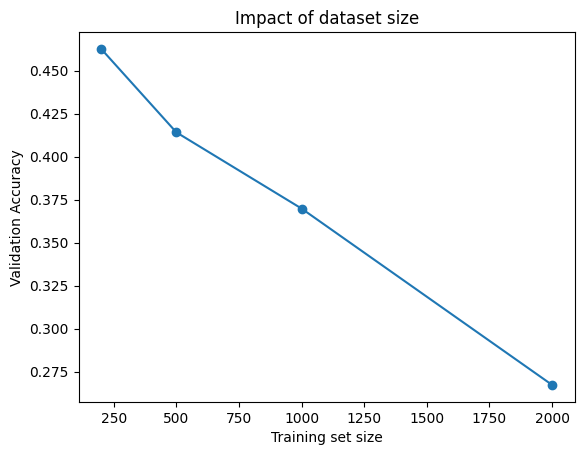

In [21]:
#Ejercicio 4.4. Impacto del tamaño del dataset
#Definir tamaños
dataset_sizes = [200, 500, 1000, 2000]
#Función para entrenar
def train_model(X_train, y_train, X_val, y_val, epochs=20):
    
    model = nn.Sequential(
        nn.Linear(2400, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        loss.backward()
        optimizer.step()
    
    # Evaluación
    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(X_val))
        val_preds = (val_probs.numpy() > 0.5).astype(int)
        acc = (val_preds == y_val.numpy()).mean()
    
    return acc
#loop sobre tamaños
results = []

for size in dataset_sizes:
    
    # subset
    X_train_sub = X_train[:size]
    y_train_sub = y_train[:size]
    
    acc = train_model(X_train_sub, y_train_sub, X_val, y_val)
    
    print(f"Size: {size} → Val Accuracy: {acc:.4f}")
    
    results.append(acc)
#Graficar
import matplotlib.pyplot as plt

plt.plot(dataset_sizes, results, marker='o')

plt.xlabel("Training set size")
plt.ylabel("Validation Accuracy")
plt.title("Impact of dataset size")

plt.savefig("../results/dataset_size_4_4.png")
plt.show()

Interpretacion de los resultados
A medida que aumento datos, la performance baja. Normalmente esperaríamos que con más datos de entrenamiento, la performance aumente, acá pasa lo contrario.
Lo que está pasando es lo siguiente:
Con pocos datos (200) el modelo puede: memorizar, encontrar patrones espurios, “tener suerte”
Con muchos datos (2000) el dataset: representa mejor la realidad lo que dificulta la tarea de clasificación, incluye más variabilidad, elimina patrones falsos.
Lo que indica que el modelo ya no puede “hacer trampa”. Estos resultados indican que el modelo utilizado no tiene la capacidad suficiente para capturar la complejidad del problema cuando se dispone de una mayor cantidad de datos, evidenciando sus limitaciones.
Entonces más datos no siempre mejoran el rendimiento si el modelo es inadecuado.


Sequence length: 50
Validation Accuracy: 0.2313

Sequence length: 100
Validation Accuracy: 0.1967

Sequence length: 200
Validation Accuracy: 0.1427

Sequence length: 400
Validation Accuracy: 0.1579

Sequence length: 600
Validation Accuracy: 0.1357


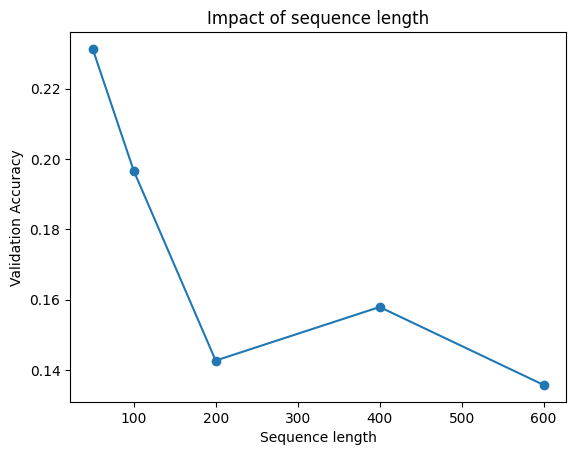

In [22]:
#Ejercicio 4.5 — impacto del tamaño de la secuencia
#Definir tamaños
seq_lengths = [50, 100, 200, 400, 600]
#Función para recortar secuencias
def truncate_sequence(seq, length):
    return seq[:length]
#Loop principal (recortar secuencias, reencodear, entrenar, evaluar)
results_seq = []

for L in seq_lengths:
    
    print(f"\nSequence length: {L}")
    
    # recortar
    train_seqs_L = [truncate_sequence(seq, L) for seq in train_seqs]
    val_seqs_L = [truncate_sequence(seq, L) for seq in val_seqs]
    
    # encoding
    encoded_train = np.array([one_hot_encode(seq) for seq in train_seqs_L])
    encoded_val = np.array([one_hot_encode(seq) for seq in val_seqs_L])
    
    # flatten
    X_train_L = torch.tensor(encoded_train, dtype=torch.float32).view(len(train_seqs_L), -1)
    X_val_L = torch.tensor(encoded_val, dtype=torch.float32).view(len(val_seqs_L), -1)
    
    y_train_L = y_train
    y_val_L = y_val
    
    # modelo ajustado al tamaño
    input_size = L * 4
    
    model = nn.Sequential(
        nn.Linear(input_size, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # entrenamiento rápido
    for epoch in range(20):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train_L)
        loss = criterion(outputs, y_train_L)
        
        loss.backward()
        optimizer.step()
    
    # evaluación
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_val_L))
        preds = (probs.numpy() > 0.5).astype(int)
        acc = (preds == y_val_L.numpy()).mean()
    
    print(f"Validation Accuracy: {acc:.4f}")
    results_seq.append(acc)
#Graficar
import matplotlib.pyplot as plt

plt.plot(seq_lengths, results_seq, marker='o')

plt.xlabel("Sequence length")
plt.ylabel("Validation Accuracy")
plt.title("Impact of sequence length")

plt.savefig("../results/sequence_length_4_5.png")
plt.show()

Observación: A mayor longitud, la performance empeora.
Lo que está pasando es que cuando usamos secuencias más largas:aumentamos features (input = L × 4), aumentamos ruido, aumentamos complejidad. Entonces el modelo: no puede manejar la dimensionalidad del problema, no encuentra patrones claros, se “pierde” en la información. 
Con L = 50 mejor performance (~0.23), con L = 600 peor (~0.13), lo que indica que más información perjudica al modelo.
En el Ejercicio 4.3 vimos que el problema difícil, en el ejercicio 4.4 corroboramos que más datos no ayudan y en el ejercicio 4.5 vimos que más features tampoco. Entonces el problema no es la falta de datos ni de longitud, sino que el modelo es insuficiente 
Agregar más información sin un modelo adecuado puede degradar el rendimiento

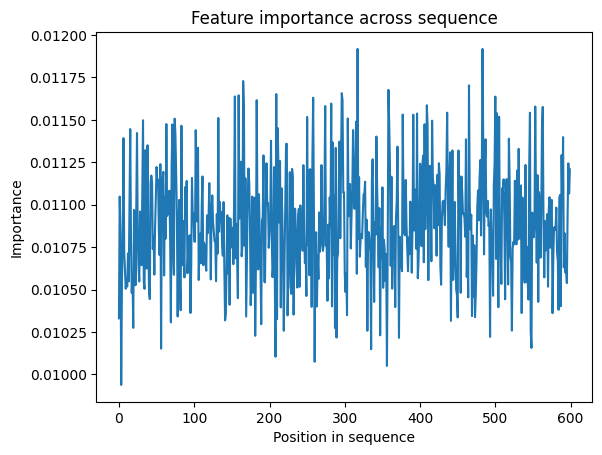

In [24]:
#Ejercicio 4.6 - Interpretabilidad
#Análisis de pesos de la primera capa
#Extraer pesos
# pesos de la primera capa
weights = model[0].weight.detach().numpy()  # shape: (128, input_size)
#promediar importancia (queremos importancia por feature)
import numpy as np

importance = np.mean(np.abs(weights), axis=0)
#Volver a formato biológico
#Cada posicion = 4 valores (A, T, C, G)
L = 600  # o el largo que usaste

importance_matrix = importance.reshape(L, 4)
#Importancia por posicion
pos_importance = importance_matrix.mean(axis=1)
#Graficar
import matplotlib.pyplot as plt

plt.plot(pos_importance)

plt.xlabel("Position in sequence")
plt.ylabel("Importance")
plt.title("Feature importance across sequence")

plt.savefig("../results/feature_importance_4_6.png")
plt.show()

Interpretabilidad del modelo: 
Se analizó la importancia de las características a partir de los pesos de la primera capa de la red neuronal. Los resultados muestran una distribución relativamente uniforme de la importancia a lo largo de la secuencia, sin la presencia de regiones claramente dominantes.
Esto sugiere que el modelo no ha logrado identificar motivos específicos asociados a promotores, sino que distribuye su atención de manera difusa. Este comportamiento es consistente con la baja performance observada en los experimentos anteriores, particularmente al utilizar negativos realistas.
En un contexto biológico, se esperaría que ciertas regiones de la secuencia (como elementos promotores conservados) tuvieran mayor relevancia. La ausencia de este patrón indica que la arquitectura utilizada no es suficiente para capturar las características discriminativas del problema. Ver gráfico feature_importance_4_6.png de la carpeta results en la carpeta principal del repositorio del tp.